Titos Abimanyu

## Penjelasan Awal



Dataset ini awalnya bersumber dari National Institute of Diabetes and Digestive and Kidney Diseases. Tujuan utama dari dataset ini adalah untuk memprediksi secara diagnostik apakah seorang pasien mengidap penyakit diabetes atau tidak, berdasarkan beberapa hasil pengukuran medis yang disertakan. Secara khusus, seluruh pasien dalam dataset ini adalah perempuan berusia minimal 21 tahun ke atas dan memiliki garis keturunan dari suku Pima Indian (penduduk asli Amerika).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.core.display import display, HTML
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.initializers import HeNormal, GlorotNormal
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint


### Load Data

In [ ]:
!wget -O dataset.zip uciml/pima-indians-diabetes-database
!kaggle datasets download -d uciml/pima-indians-diabetes-database
!unzip pima-indians-diabetes-database.zip

--2026-06-24 11:26:50--  http://uciml/pima-indians-diabetes-database
Resolving uciml (uciml)... failed: Name or service not known.
wget: unable to resolve host address ‘uciml’
Dataset URL: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
License(s): CC0-1.0
100% 8.91k/8.91k [00:00<00:00, 30.8MB/s]

Archive:  pima-indians-diabetes-database.zip
  inflating: diabetes.csv            


In [ ]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Data Understanding

In [ ]:
df_diabetes = df.copy()
df_diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df_diabetes.shape

(768, 9)

In [ ]:
missing_value = pd.DataFrame({
    'Jumlah Missing': df_diabetes.isnull().sum(),
    'Persentase (%)': round(df_diabetes.isnull().mean()*100,2)
})

missing_value

,Jumlah Missing,Persentase (%)
Pregnancies,0,0.0
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0
DiabetesPedigreeFunction,0,0.0
Age,0,0.0
Outcome,0,0.0


In [ ]:
duplicate = df_diabetes.duplicated().sum()

print(f"Jumlah Data Duplikat : {duplicate}")

Jumlah Data Duplikat : 0


setelah dataset dilihat tidak ditemukan duplikat dan juga data kosong atau null

In [ ]:
df_diabetes.nunique() #melihat nilai unik

,0
Pregnancies,17
Glucose,136
BloodPressure,47
SkinThickness,51
Insulin,186
BMI,248
DiabetesPedigreeFunction,517
Age,52
Outcome,2


In [ ]:
kolom_missing = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

df_diabetes[kolom_missing] = df_diabetes[kolom_missing].replace(0, np.nan)

In [ ]:
df_diabetes.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
for col in kolom_missing:
    df_diabetes[col] = df_diabetes[col].fillna(df_diabetes[col].median())

In [ ]:
df_diabetes.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df_diabetes

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


In [ ]:
df_diabetes.columns.tolist()

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome']

In [ ]:
numerical_features = df.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = df.select_dtypes(
    include=['object']
).columns.tolist()

print("Numerical Features")
print(numerical_features)

print("\nCategorical Features")
print(categorical_features)

Numerical Features
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Categorical Features
[]


In [ ]:
df_diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Statistik deskriptif

In [ ]:
numerical_cols = df_diabetes.select_dtypes(include=['int64','float64']).columns

for col in numerical_cols:
    mean = df[col].mean()
    median = df[col].median()
    mode = df[col].mode()[0]

    print(f"\nStatistik Deskriptif Kolom {col}")
    print("-"*40)
    print(f"Mean   : {mean:.2f}")
    print(f"Median : {median:.2f}")
    print(f"Mode   : {mode:.2f}")


Statistik Deskriptif Kolom Pregnancies
----------------------------------------
Mean   : 3.85
Median : 3.00
Mode   : 1.00

Statistik Deskriptif Kolom Glucose
----------------------------------------
Mean   : 120.89
Median : 117.00
Mode   : 99.00

Statistik Deskriptif Kolom BloodPressure
----------------------------------------
Mean   : 69.11
Median : 72.00
Mode   : 70.00

Statistik Deskriptif Kolom SkinThickness
----------------------------------------
Mean   : 20.54
Median : 23.00
Mode   : 0.00

Statistik Deskriptif Kolom Insulin
----------------------------------------
Mean   : 79.80
Median : 30.50
Mode   : 0.00

Statistik Deskriptif Kolom BMI
----------------------------------------
Mean   : 31.99
Median : 32.00
Mode   : 32.00

Statistik Deskriptif Kolom DiabetesPedigreeFunction
----------------------------------------
Mean   : 0.47
Median : 0.37
Mode   : 0.25

Statistik Deskriptif Kolom Age
----------------------------------------
Mean   : 33.24
Median : 29.00
Mode   : 22.00

Stat

## Cek distribusi data

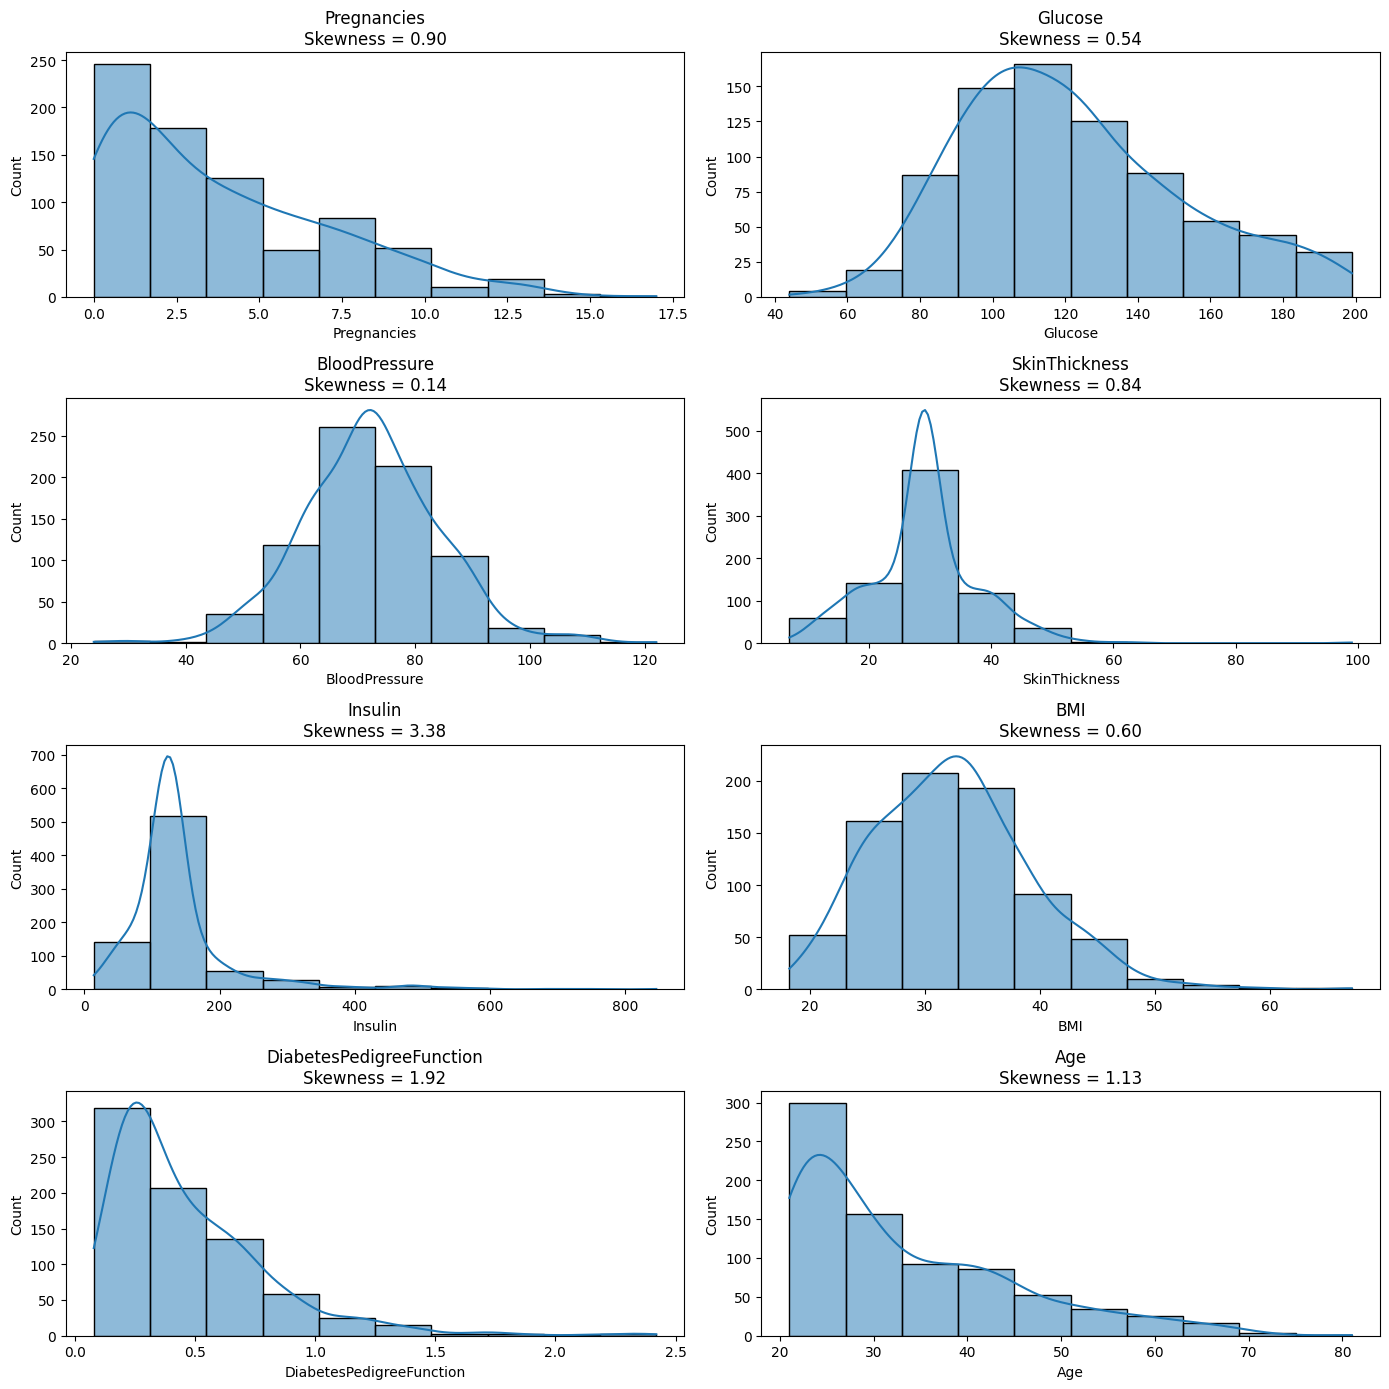

In [ ]:
numerical_cols = df_diabetes.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

# Hilangkan target
numerical_cols.remove('Outcome')

fig, ax = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(14, 14)
)

ax = ax.flatten()

for i, col in enumerate(numerical_cols):

    sns.histplot(
        data=df_diabetes,
        x=col,
        kde=True,
        bins=10,
        ax=ax[i]
    )

    skewness = df_diabetes[col].skew()

    ax[i].set_title(
        f'{col}\nSkewness = {skewness:.2f}'
    )

plt.tight_layout()
plt.show()

In [ ]:
skewness_df = pd.DataFrame({
    'Feature': numerical_cols,
    'Skewness': [df[col].skew() for col in numerical_cols]
})

skewness_df

,Feature,Skewness
0,Pregnancies,0.901674
1,Glucose,0.173754
2,BloodPressure,-1.843608
3,SkinThickness,0.109372
4,Insulin,2.272251
5,BMI,-0.428982
6,DiabetesPedigreeFunction,1.919911
7,Age,1.129597


In [ ]:
for col in numerical_cols:

    skew = df_diabetes[col].skew()

    if -0.5 <= skew <= 0.5:
        kategori = "Simetris / Normal"
    elif skew > 0.5:
        kategori = "Right Skewed"
    else:
        kategori = "Left Skewed"

    print(f"{col:<25} : {skew:.2f} ({kategori})")

Pregnancies               : 0.90 (Right Skewed)
Glucose                   : 0.54 (Right Skewed)
BloodPressure             : 0.14 (Simetris / Normal)
SkinThickness             : 0.84 (Right Skewed)
Insulin                   : 3.38 (Right Skewed)
BMI                       : 0.60 (Right Skewed)
DiabetesPedigreeFunction  : 1.92 (Right Skewed)
Age                       : 1.13 (Right Skewed)


In [ ]:
# Pakai D'Agostino's K^2 Test
column_of_normal_distribution = []
column_of_abnormal_distribution = []

for col in numerical_cols:

    statistic, p_value = stats.normaltest(df_diabetes[col])

    print(f"\n{col}")
    print(f"P-Value : {p_value:.20f}")

    if p_value > 0.05:
        column_of_normal_distribution.append(col)
        print("Kesimpulan : Berdistribusi Normal")

    else:
        column_of_abnormal_distribution.append(col)
        print("Kesimpulan : Tidak Berdistribusi Normal")


Pregnancies
P-Value : 0.00000000000000000391
Kesimpulan : Tidak Berdistribusi Normal

Glucose
P-Value : 0.00000001852106007582
Kesimpulan : Tidak Berdistribusi Normal

BloodPressure
P-Value : 0.00002733730156500326
Kesimpulan : Tidak Berdistribusi Normal

SkinThickness
P-Value : 0.00000000000000000000
Kesimpulan : Tidak Berdistribusi Normal

Insulin
P-Value : 0.00000000000000000000
Kesimpulan : Tidak Berdistribusi Normal

BMI
P-Value : 0.00000000000132163826
Kesimpulan : Tidak Berdistribusi Normal

DiabetesPedigreeFunction
P-Value : 0.00000000000000000000
Kesimpulan : Tidak Berdistribusi Normal

Age
P-Value : 0.00000000000000000000
Kesimpulan : Tidak Berdistribusi Normal


In [ ]:
# Pakai Shapiro-Wilk Test
from scipy.stats import shapiro

for col in column_of_abnormal_distribution:

    statistic, p_value = stats.shapiro(df_diabetes[col])

    print(f"\nKolom : {col}")
    print(f"Statistic : {statistic:.5f}")
    print(f"P-Value   : {p_value:.10f}")

    if p_value > 0.05:
        print("Kesimpulan : Berdistribusi Normal")
    else:
        print("Kesimpulan : Tidak Berdistribusi Normal")


Kolom : Pregnancies
Statistic : 0.90428
P-Value   : 0.0000000000
Kesimpulan : Tidak Berdistribusi Normal

Kolom : Glucose
Statistic : 0.96962
P-Value   : 0.0000000000
Kesimpulan : Tidak Berdistribusi Normal

Kolom : BloodPressure
Statistic : 0.98782
P-Value   : 0.0000052557
Kesimpulan : Tidak Berdistribusi Normal

Kolom : SkinThickness
Statistic : 0.92784
P-Value   : 0.0000000000
Kesimpulan : Tidak Berdistribusi Normal

Kolom : Insulin
Statistic : 0.64151
P-Value   : 0.0000000000
Kesimpulan : Tidak Berdistribusi Normal

Kolom : BMI
Statistic : 0.97944
P-Value   : 0.0000000064
Kesimpulan : Tidak Berdistribusi Normal

Kolom : DiabetesPedigreeFunction
Statistic : 0.83652
P-Value   : 0.0000000000
Kesimpulan : Tidak Berdistribusi Normal

Kolom : Age
Statistic : 0.87477
P-Value   : 0.0000000000
Kesimpulan : Tidak Berdistribusi Normal


Nilai p-value yang dihasilkan dari masing-masing kolom berada di bawah 0.05, hal ini menunjukkan bahwa data tidak terdistribusi secara normal.

## Handling Outlier

Pengujian menunjukkan bahwa nilai p-value berada di bawah 0,05. Oleh karena itu, handling outlier dialihkan menggunakan Tukey's Law yang berbasis pada nilai kuartil data untuk menyaring nilai ekstrem di luar batas atas dan batas bawah.

In [ ]:
column_of_normal_distribution

[]

In [ ]:
column_of_abnormal_distribution

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

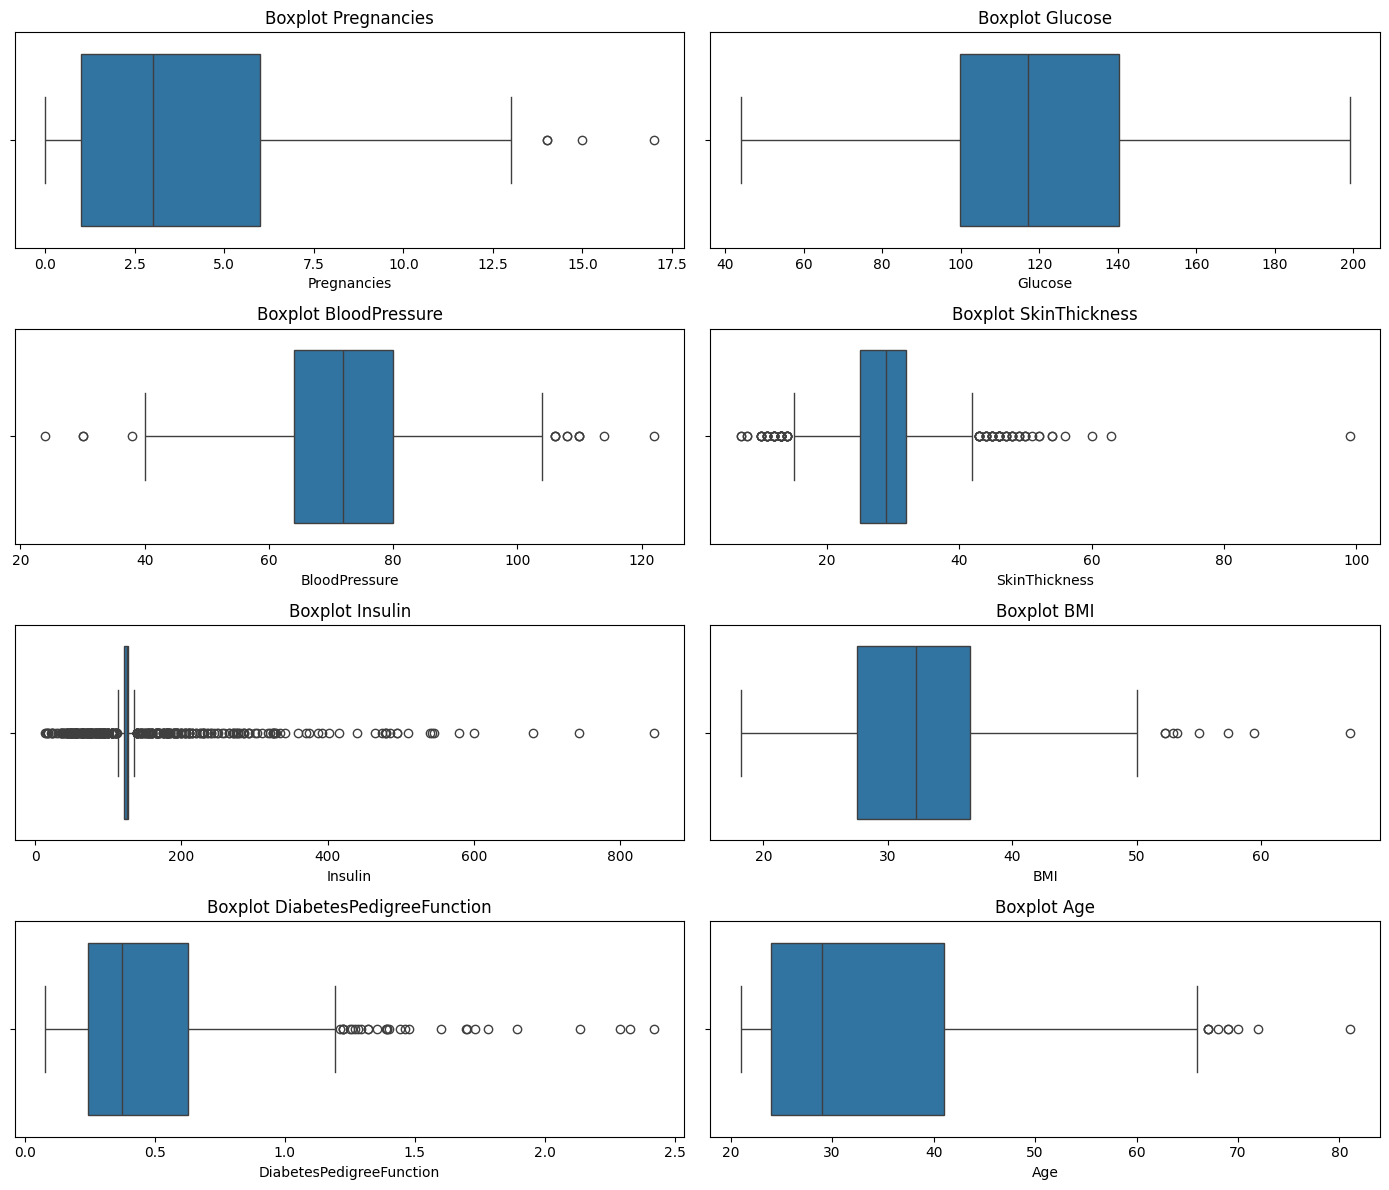

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12))

axes = axes.flatten()

for i, col in enumerate(numerical_cols):

    sns.boxplot(
        x=df_diabetes[col],
        ax=axes[i]
    )

    axes[i].set_title(f'Boxplot {col}')

plt.tight_layout()
plt.show()

In [ ]:
outlier_summary = []

for col in numerical_cols:

    Q1 = df_diabetes[col].quantile(0.25)
    Q3 = df_diabetes[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df_diabetes[
        (df_diabetes[col] < lower_bound) |
        (df_diabetes[col] > upper_bound)
    ]

    outlier_summary.append([
        col,
        len(outliers),
        round((len(outliers)/len(df_diabetes))*100, 2)
    ])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=[
        'Feature',
        'Jumlah Outlier',
        'Persentase (%)'
    ]
)

outlier_df

,Feature,Jumlah Outlier,Persentase (%)
0,Pregnancies,4,0.52
1,Glucose,0,0.00
2,BloodPressure,14,1.82
3,SkinThickness,87,11.33
4,Insulin,346,45.05
5,BMI,8,1.04
6,DiabetesPedigreeFunction,29,3.78
7,Age,9,1.17


### Mengevaluasi Outlier menggunakan Capping

Berdasarkan metode IQR, ditemukan outlier pada beberapa fitur seperti Pregnancies, Insulin, DiabetesPedigreeFunction, dan Age. Namun karena dataset yang digunakan merupakan data kesehatan, nilai ekstrem tidak selalu menunjukkan kesalahan data dan dapat merepresentasikan kondisi pasien yang sebenarnya

In [ ]:
df_diabetes_clean = df_diabetes.copy()

for col in numerical_cols:

    Q1 = df_diabetes_clean[col].quantile(0.25)
    Q3 = df_diabetes_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    df_diabetes_clean[col] = np.where(
        df_diabetes_clean[col] < lower_bound,
        lower_bound,
        df_diabetes_clean[col]
    )

    df_diabetes_clean[col] = np.where(
        df_diabetes_clean[col] > upper_bound,
        upper_bound,
        df_diabetes_clean[col]
    )

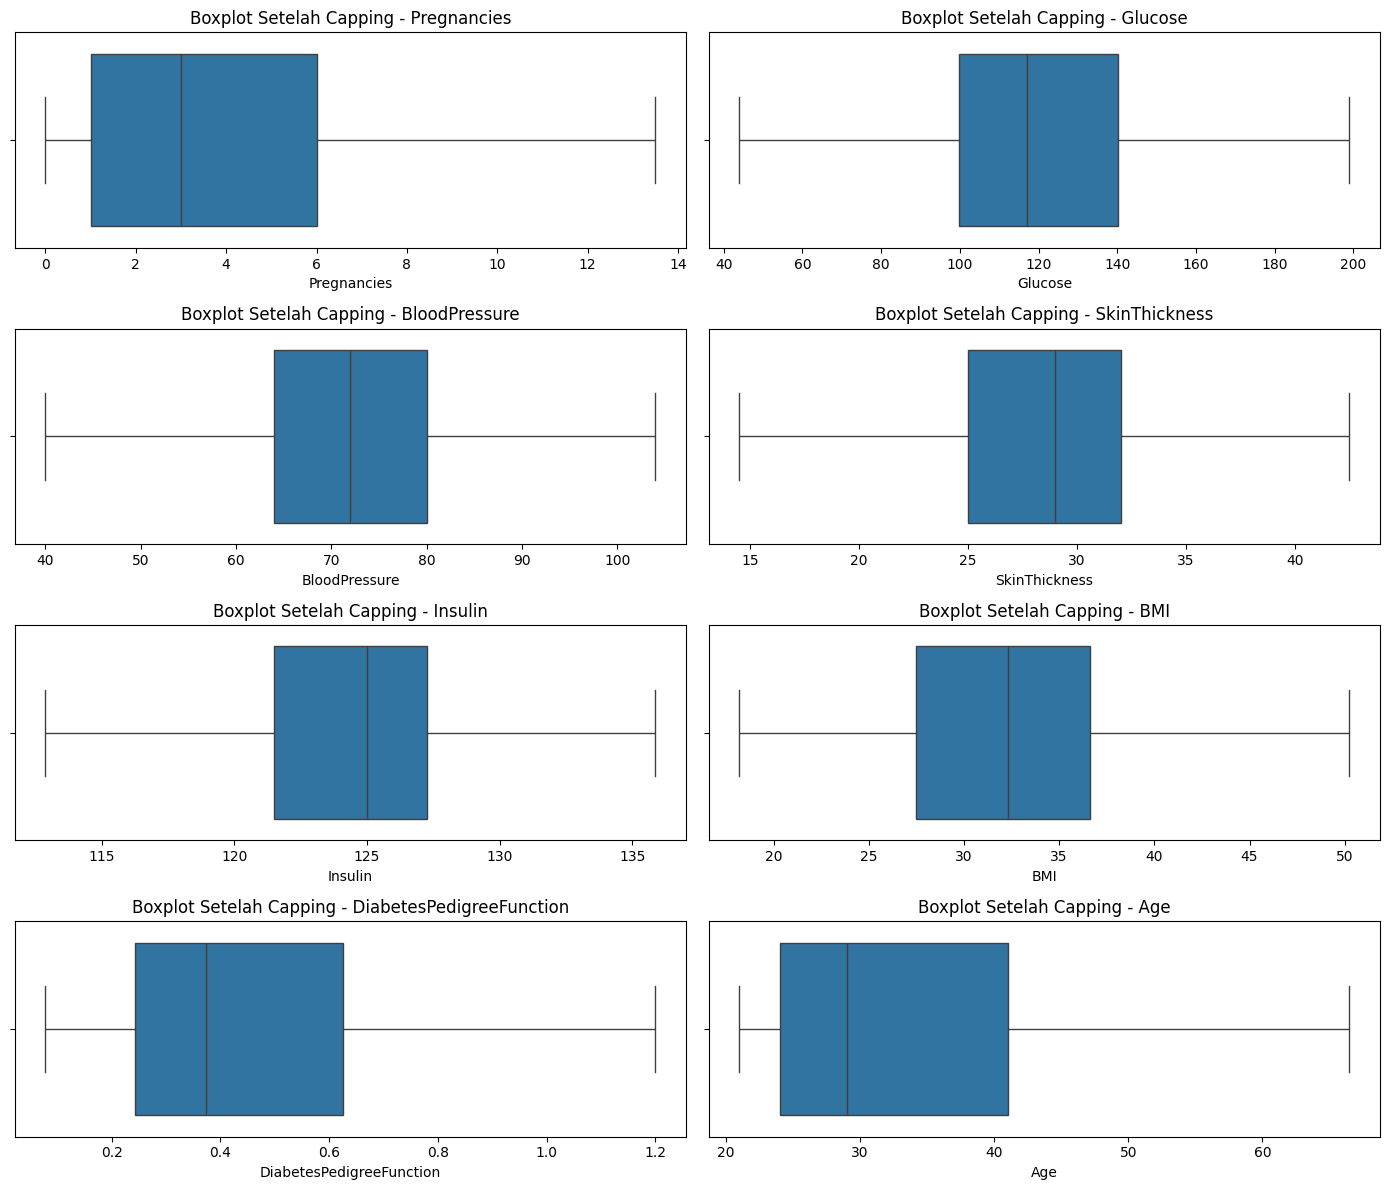

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12))

axes = axes.flatten()

for i, col in enumerate(numerical_cols):

    sns.boxplot(
        x=df_diabetes_clean[col],
        ax=axes[i]
    )

    axes[i].set_title(f'Boxplot Setelah Capping - {col}')

plt.tight_layout()
plt.show()

In [ ]:
sisa_outlier_min = (df_diabetes_clean[col] < lower_bound).sum()
sisa_outlier_max = (df_diabetes_clean[col] > upper_bound).sum()

print(f"Jumlah Outlier Min (Bawah): {sisa_outlier_min}")
print(f"Jumlah Outlier Max (Atas) : {sisa_outlier_max}")

Jumlah Outlier Min (Bawah): 0
Jumlah Outlier Max (Atas) : 0


## Korelasi

Berdasarkan hasil analisis distribusi data dan uji normalitas, sebagian besar fitur tidak berdistribusi normal. Oleh karena itu, digunakan Spearman Correlation yang lebih sesuai untuk data non-normal dan mampu mengukur hubungan monotonik antar variabel.

In [ ]:
corr_spearman = df_diabetes_clean.corr(method='spearman')

corr_spearman

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128849,0.189612,0.092535,0.092425,0.000659,-0.042838,0.607189,0.198689
Glucose,0.128849,1.000000,0.242639,0.187609,0.440113,0.225405,0.090131,0.281873,0.481397
BloodPressure,0.189612,0.242639,1.000000,0.203336,0.096162,0.289793,0.009924,0.366269,0.170851
SkinThickness,0.092535,0.187609,0.203336,1.000000,0.201094,0.549395,0.058868,0.182387,0.215474
Insulin,0.092425,0.440113,0.096162,0.201094,1.000000,0.196312,0.081588,0.181774,0.268300
BMI,0.000659,0.225405,0.289793,0.549395,0.196312,1.000000,0.134010,0.120643,0.307021
DiabetesPedigreeFunction,-0.042838,0.090131,0.009924,0.058868,0.081588,0.134010,1.000000,0.043147,0.175851
Age,0.607189,0.281873,0.366269,0.182387,0.181774,0.120643,0.043147,1.000000,0.309053
Outcome,0.198689,0.481397,0.170851,0.215474,0.268300,0.307021,0.175851,0.309053,1.000000


In [ ]:
corr_target = (
    df_diabetes_clean
    .corr(method='spearman')['Outcome']
    .sort_values(ascending=False)
)

corr_target

,Outcome
Outcome,1.000000
Glucose,0.481397
Age,0.309053
BMI,0.307021
Insulin,0.268300
SkinThickness,0.215474
Pregnancies,0.198689
DiabetesPedigreeFunction,0.175851
BloodPressure,0.170851


Berdasarkan analisis Spearman Correlation, fitur Glucose memiliki hubungan positif paling kuat terhadap Outcome. Selain itu, BMI, Age, dan Pregnancies juga menunjukkan hubungan positif terhadap kemungkinan seseorang menderita diabetes. Hal ini menunjukkan bahwa peningkatan nilai pada fitur-fitur tersebut cenderung meningkatkan risiko diabetes.

### VIF

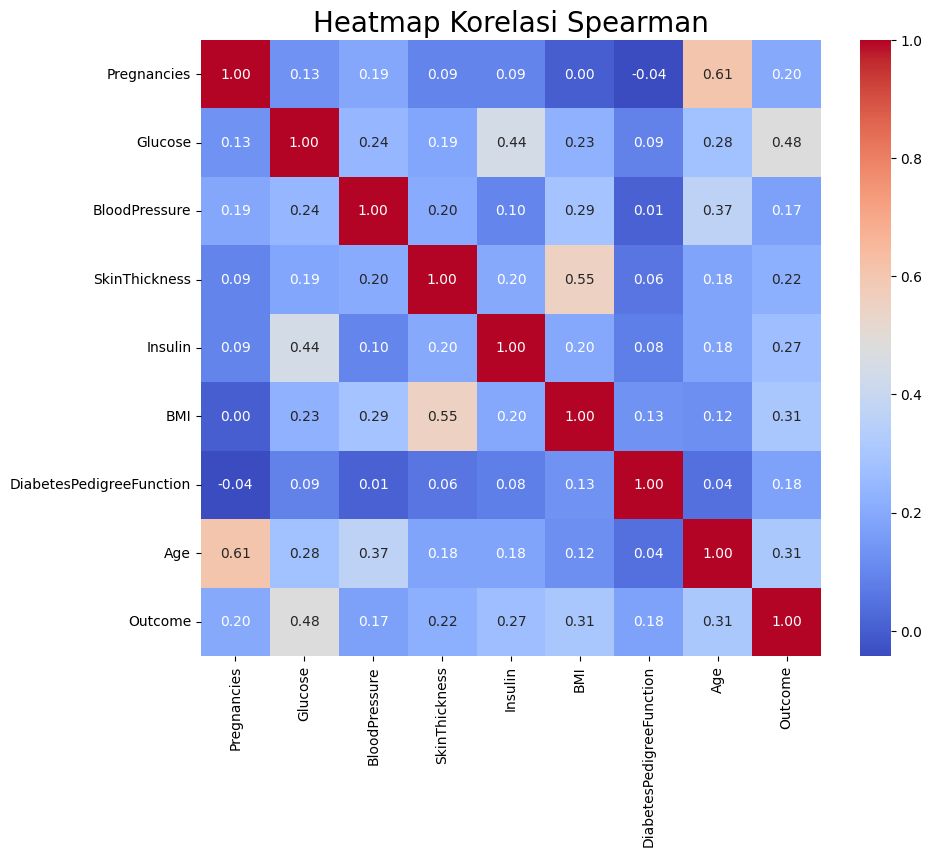

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df_diabetes_clean.corr(method='spearman'),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Heatmap Korelasi Spearman', fontsize=20)
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(X):

    vif = pd.DataFrame()

    vif["Variables"] = X.columns

    vif["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]

    return vif

In [ ]:
X = df_diabetes_clean.drop(columns='Outcome')

X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148.0,72.0,35.0,125.000,33.6,0.627,50.0
1,1.0,85.0,66.0,29.0,125.000,26.6,0.351,31.0
2,8.0,183.0,64.0,29.0,125.000,23.3,0.672,32.0
3,1.0,89.0,66.0,23.0,112.875,28.1,0.167,21.0
4,0.0,137.0,40.0,35.0,135.875,43.1,1.200,33.0


In [ ]:
calc_vif(X).sort_values(
    by='VIF',
    ascending=False
)

,Variables,VIF
4,Insulin,61.175356
2,BloodPressure,45.140405
5,BMI,39.414907
3,SkinThickness,24.084400
1,Glucose,21.481907
7,Age,14.987236
6,DiabetesPedigreeFunction,3.708540
0,Pregnancies,3.340656


In [ ]:
vif_df = calc_vif(X)

def kategori_vif(vif):

    if vif < 5:
        return 'Tidak Ada Multikolinearitas'

    elif vif < 10:
        return 'Multikolinearitas Sedang'

    else:
        return 'Multikolinearitas Tinggi'

vif_df['Interpretasi'] = vif_df['VIF'].apply(kategori_vif)

vif_df.sort_values(
    by='VIF',
    ascending=False
)

,Variables,VIF,Interpretasi
4,Insulin,61.175356,Multikolinearitas Tinggi
2,BloodPressure,45.140405,Multikolinearitas Tinggi
5,BMI,39.414907,Multikolinearitas Tinggi
3,SkinThickness,24.084400,Multikolinearitas Tinggi
1,Glucose,21.481907,Multikolinearitas Tinggi
7,Age,14.987236,Multikolinearitas Tinggi
6,DiabetesPedigreeFunction,3.708540,Tidak Ada Multikolinearitas
0,Pregnancies,3.340656,Tidak Ada Multikolinearitas


## EDA

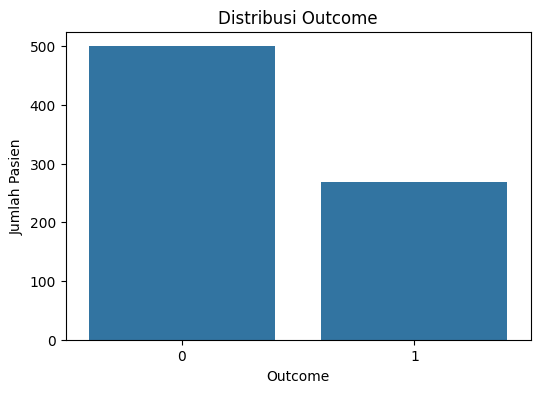

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df_diabetes_clean,
    x='Outcome'
)

plt.title('Distribusi Outcome')
plt.xlabel('Outcome')
plt.ylabel('Jumlah Pasien')

plt.show()

In [ ]:
persentase = (
    df_diabetes_clean['Outcome']
    .value_counts(normalize=True)
    * 100
)

persentase

,proportion
Outcome,
0,65.104167
1,34.895833


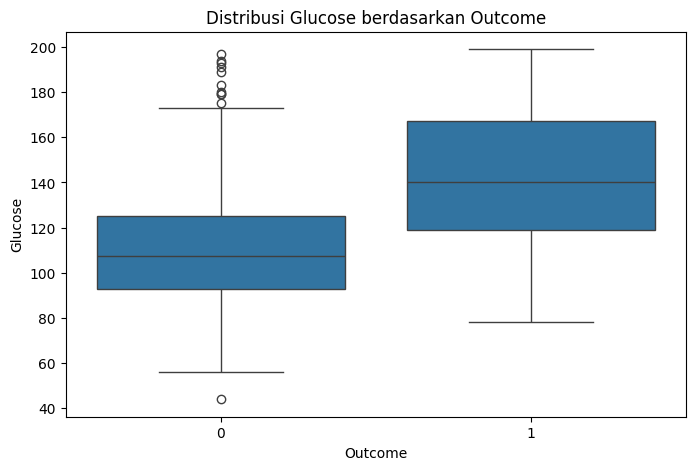

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_diabetes_clean,
    x='Outcome',
    y='Glucose'
)

plt.title('Distribusi Glucose berdasarkan Outcome')

plt.show()

Pasien diabetes memiliki kadar glukosa yang cenderung lebih tinggi dibandingkan pasien non-diabetes.

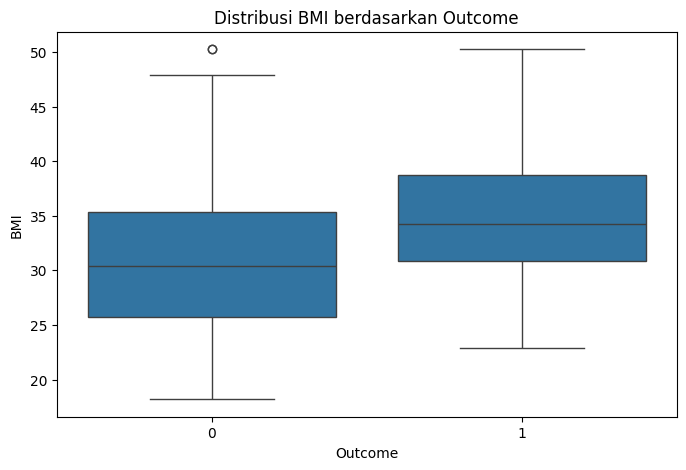

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_diabetes_clean,
    x='Outcome',
    y='BMI'
)

plt.title('Distribusi BMI berdasarkan Outcome')

plt.show()

Pasien diabetes cenderung memiliki BMI yang lebih tinggi.

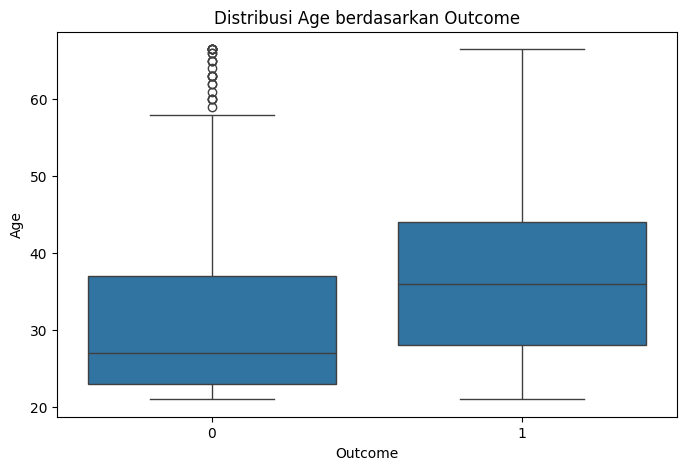

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_diabetes_clean,
    x='Outcome',
    y='Age'
)

plt.title('Distribusi Age berdasarkan Outcome')

plt.show()

Risiko diabetes cenderung meningkat pada kelompok usia yang lebih tua.

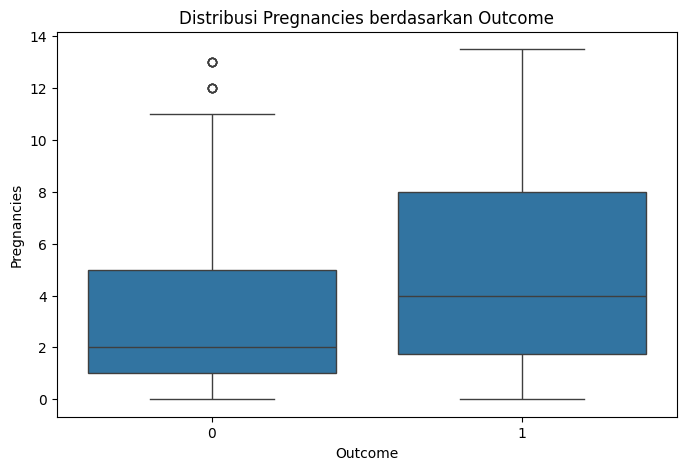

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_diabetes_clean,
    x='Outcome',
    y='Pregnancies'
)

plt.title('Distribusi Pregnancies berdasarkan Outcome')

plt.show()

Jumlah kehamilan yang lebih tinggi cenderung ditemukan pada kelompok pasien diabetes.

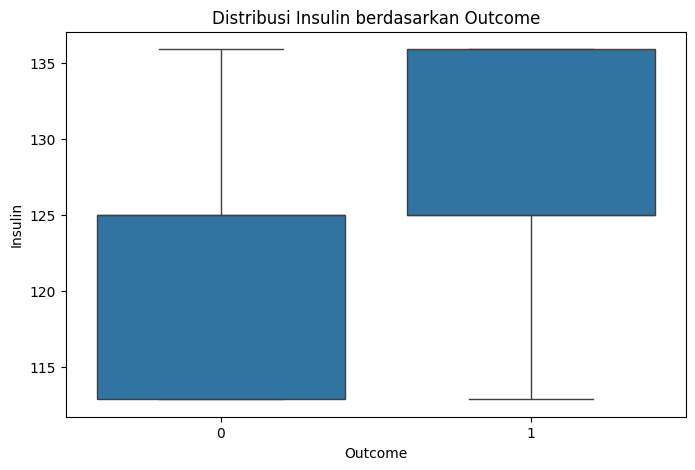

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_diabetes_clean,
    x='Outcome',
    y='Insulin'
)

plt.title('Distribusi Insulin berdasarkan Outcome')

plt.show()

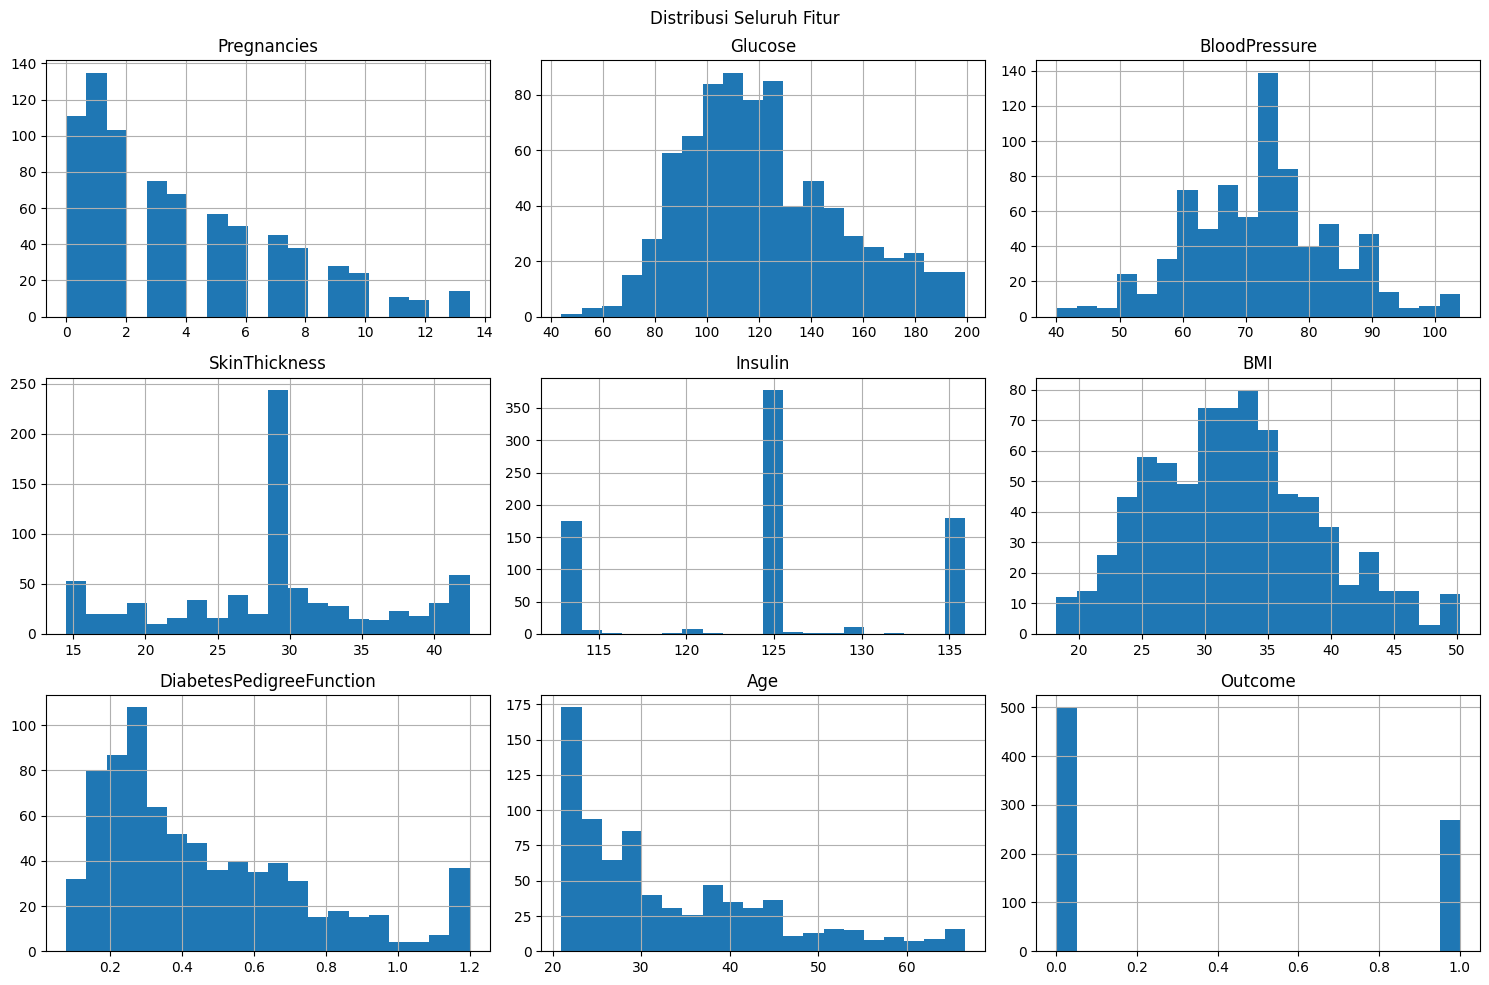

In [ ]:
df_diabetes_clean.hist(
    figsize=(15,10),
    bins=20
)

plt.suptitle('Distribusi Seluruh Fitur')
plt.tight_layout()
plt.show()

Berdasarkan hasil EDA, fitur Glucose menunjukkan perbedaan yang paling jelas antara pasien diabetes dan non-diabetes. Selain itu, BMI, Age, dan Pregnancies juga memiliki hubungan positif terhadap risiko diabetes. Hasil ini sejalan dengan analisis korelasi Spearman yang menunjukkan bahwa fitur-fitur tersebut memiliki korelasi tertinggi terhadap Outcome.

## Feature Engineering

### Splitting data

In [ ]:
X = df_diabetes_clean.drop(columns='Outcome')
y = df_diabetes_clean['Outcome']

print("Shape X :", X.shape)
print("Shape y :", y.shape)

Shape X : (768, 8)
Shape y : (768,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X Train :", X_train.shape)
print("X Test  :", X_test.shape)
print("y Train :", y_train.shape)
print("y Test  :", y_test.shape)

X Train : (614, 8)
X Test  : (154, 8)
y Train : (614,)
y Test  : (154,)


## Feature Scaling

Feature Scaling menggunakan RobustScaler diterapkan untuk meningkatkan performa Logistic Regression karena model ini sensitif terhadap skala data. Pada Random Forest, model akan dilatih menggunakan data sebelum scaling karena algoritma berbasis pohon keputusan tidak dipengaruhi oleh perbedaan skala fitur.

In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

X_train_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-0.4,-0.658537,-0.625,-2.071429,-1.2125,-0.574648,0.500951,-0.294118
1,0.4,0.219512,0.375,-0.285714,-1.2125,-0.304225,0.143310,0.647059
2,-0.2,-0.292683,-0.875,1.571429,-1.2125,0.292958,-0.399493,-0.235294
3,-0.4,0.707317,-1.000,0.000000,0.0000,-0.292958,0.460368,0.000000
4,-0.6,-0.536585,-0.500,1.428571,-1.2125,1.385915,-0.041852,-0.411765


In [ ]:
X_train_scaled.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.162541,0.113927,0.006718,-0.025477,-0.031820,0.009873,0.209279,0.254072
std,0.658386,0.731800,0.736812,1.071778,0.800655,0.746077,0.728721,0.687153
min,-0.600000,-1.487805,-2.000000,-2.071429,-1.212500,-1.588732,-0.757134,-0.470588
25%,-0.400000,-0.439024,-0.500000,-0.571429,-0.500000,-0.526761,-0.348763,-0.294118
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.600000,0.560976,0.500000,0.428571,0.500000,0.473239,0.651237,0.705882
max,2.100000,2.000000,2.000000,1.928571,1.087500,2.022535,2.073557,2.205882


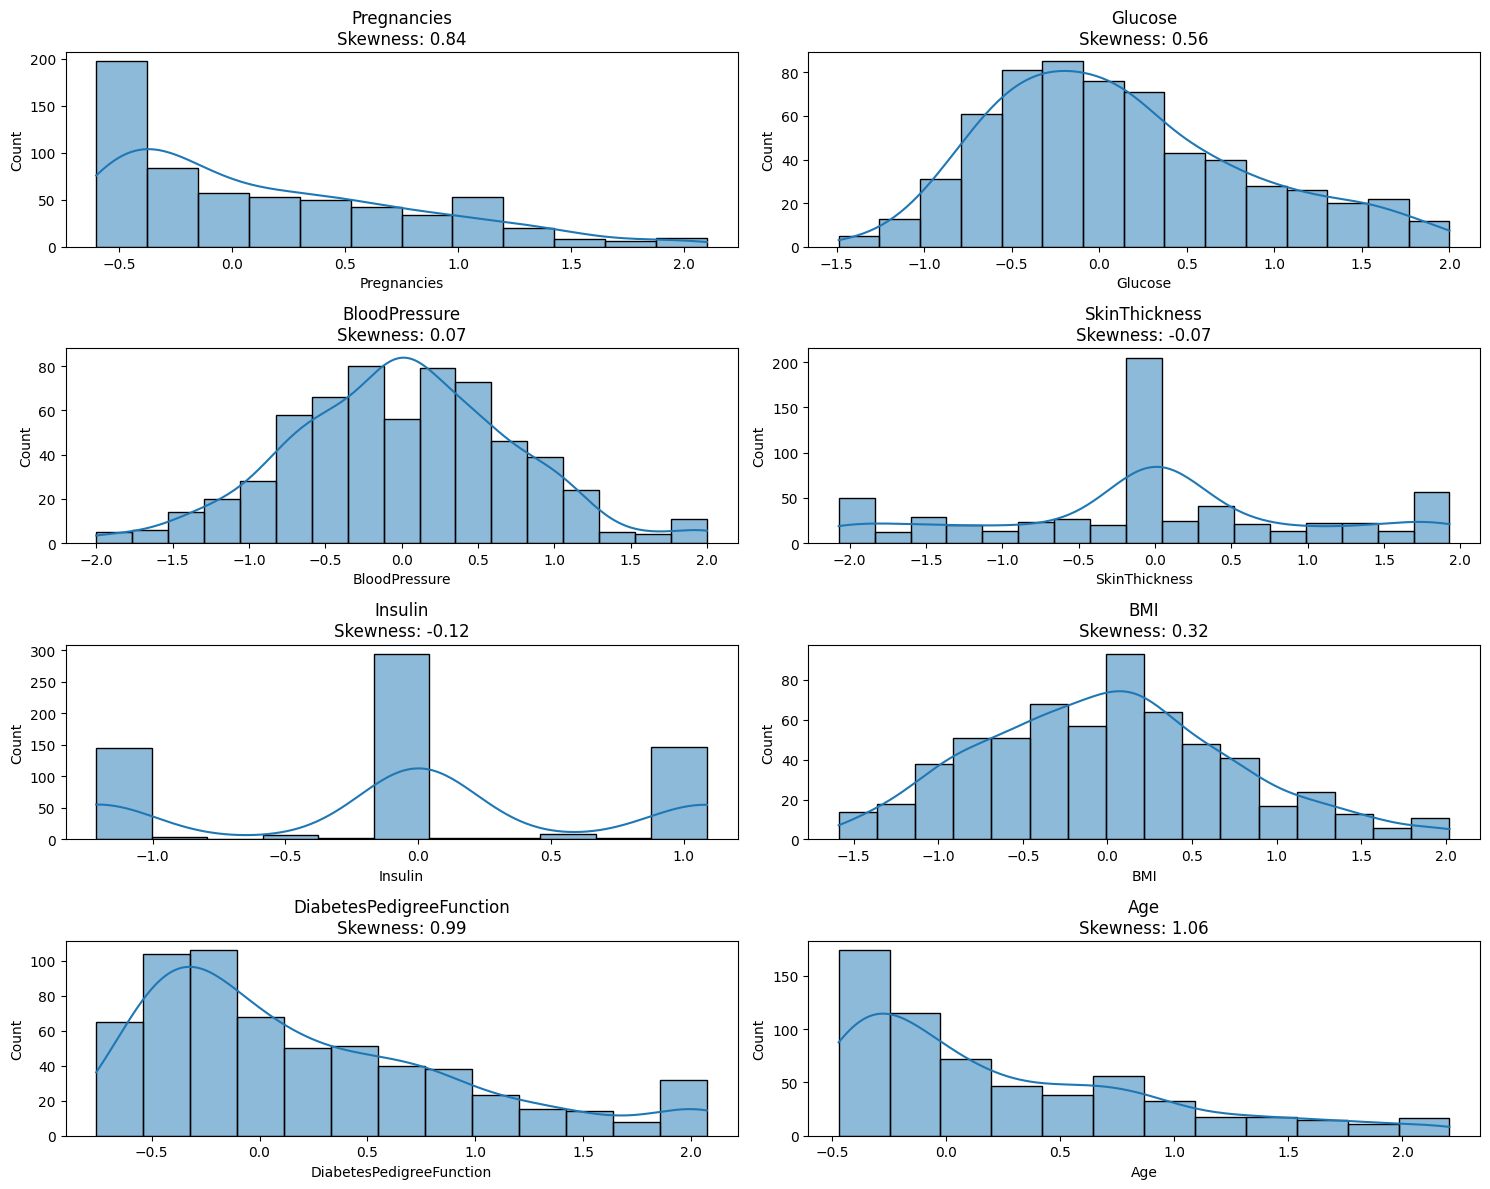

In [ ]:
fig, ax = plt.subplots(4, 2, figsize=(15, 12))

ax = ax.flatten()

for i, col in enumerate(X_train_scaled.columns):

    sns.histplot(
        X_train_scaled[col],
        kde=True,
        ax=ax[i]
    )

    skew = X_train_scaled[col].skew()

    ax[i].set_title(
        f'{col}\nSkewness: {skew:.2f}'
    )

plt.tight_layout()
plt.show()

In [ ]:
skew_after = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Skewness': X_train_scaled.skew().values
})

skew_after.sort_values(
    by='Skewness',
    ascending=False
)

,Feature,Skewness
7,Age,1.056665
6,DiabetesPedigreeFunction,0.987807
0,Pregnancies,0.840733
1,Glucose,0.556834
5,BMI,0.318036
2,BloodPressure,0.067570
3,SkinThickness,-0.070546
4,Insulin,-0.118211


Langkah feature engineering dilakukan dengan memisahkan fitur dari targetnya, yang kemudian dilanjutkan dengan pembagian data training dan testing sebesar 80:20 berbasis stratified sampling. Karena analisis sebelumnya menunjukkan adanya outlier dan distribusi data yang tidak normal, RobustScaler digunakan dalam tahap feature scaling. Penggunaan RobustScaler ini bertujuan untuk meminimalkan pengaruh nilai-nilai ekstrem secara lebih efektif daripada StandardScaler.

## Pemilihan Metode Machine Learning

### Logistic Regression

In [ ]:
logreg = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

logreg.fit(X_train_scaled, y_train)

y_pred_logreg = logreg.predict(X_test_scaled)

In [ ]:
accuracy = accuracy_score(y_test, y_pred_logreg)
precision = precision_score(y_test, y_pred_logreg)
recall = recall_score(y_test, y_pred_logreg)
f1 = f1_score(y_test, y_pred_logreg)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.7142857142857143
Precision: 0.5735294117647058
Recall   : 0.7222222222222222
F1-Score : 0.639344262295082


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01,0.1,1,10,100],
    'penalty': ['l1','l2'],
    'solver': ['liblinear']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)
best_lr = grid_lr.best_estimator_
y_pred_logreg_tuned = best_lr.predict(X_test_scaled)

print(grid_lr.best_params_)

{'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}


In [ ]:
acc_logreg = accuracy_score(y_test, y_pred_logreg_tuned)
prec_logreg = precision_score(y_test, y_pred_logreg_tuned)
rec_logreg = recall_score(y_test, y_pred_logreg_tuned)
f1_logreg = f1_score(y_test, y_pred_logreg_tuned)

print("Accuracy :", acc_logreg)
print("Precision:", prec_logreg)
print("Recall   :", rec_logreg)
print("F1 Score :", f1_logreg)

Accuracy : 0.6883116883116883
Precision: 0.56
Recall   : 0.5185185185185185
F1 Score : 0.5384615384615384


In [ ]:
hasil_logreg = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [
        acc_logreg,
        prec_logreg,
        rec_logreg,
        f1_logreg
    ]
})

hasil_logreg

,Metric,Score
0,Accuracy,0.688312
1,Precision,0.560000
2,Recall,0.518519
3,F1-Score,0.538462


Logistic Regression digunakan sebagai baseline model karena mampu memodelkan hubungan linear antara fitur dan target. Setelah dilakukan hyperparameter tuning menggunakan GridSearchCV, model menunjukkan peningkatan performa dibandingkan model awal. Nilai Accuracy, Precision, Recall, dan F1-Score menunjukkan bahwa model cukup baik dalam mengidentifikasi pasien diabetes, meskipun masih memiliki keterbatasan dalam menangkap hubungan non-linear antar fitur.

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
# Evaluasi Random Forest
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Accuracy :", acc_rf)
print("Precision:", prec_rf)
print("Recall   :", rec_rf)
print("F1 Score :", f1_rf)

Accuracy : 0.7597402597402597
Precision: 0.6808510638297872
Recall   : 0.5925925925925926
F1 Score : 0.6336633663366337


### Membandingkan Kedua Model

In [ ]:
hasil_model = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [acc_logreg, acc_rf],
    'Precision': [prec_logreg, prec_rf],
    'Recall': [rec_logreg, rec_rf],
    'F1-Score': [f1_logreg, f1_rf]
})

hasil_model

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.688312,0.560000,0.518519,0.538462
1,Random Forest,0.759740,0.680851,0.592593,0.633663


In [ ]:
hasil_model.set_index('Model').round(4)

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.6883,0.5600,0.5185,0.5385
Random Forest,0.7597,0.6809,0.5926,0.6337


### Visualisasi Perbandingan Model

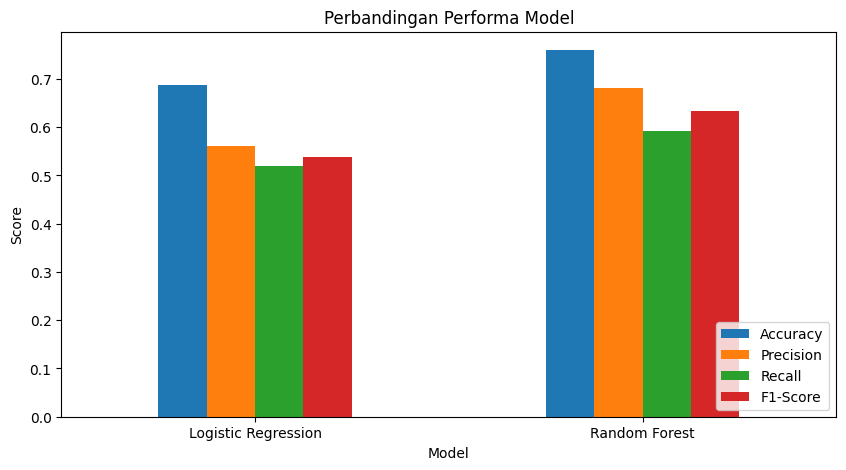

In [ ]:
hasil_model.set_index('Model').plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Perbandingan Performa Model')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')

plt.show()

# Artificial Neuron Network

In [ ]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.15,
    random_state=42,
    stratify=y_train_val
)

print(f"Train size      : {X_train.shape}")
print(f"Validation size : {X_val.shape}")
print(f"Test size       : {X_test.shape}")

Train size      : (554, 8)
Validation size : (98, 8)
Test size       : (116, 8)


In [ ]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

In [ ]:
seed = 42
tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)

model = tf.keras.models.Sequential([
    Input(shape=(8,), name='input-layer'),

    Dense(64, activation='relu', kernel_initializer='he_normal', name='hidden-layer-1'),
    Dense(32, activation='relu', kernel_initializer='he_normal', name='hidden-layer-2'),

    Dense(1, activation='sigmoid', kernel_initializer=GlorotNormal(seed), name='output-layer')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden-layer-1 (Dense)          │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden-layer-2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output-layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

1. Struktur Lapisan (Layers)
- Hidden Layer Pertama (64 Neuron): Menjadi lapisan awal yang menerima input untuk menangkap pola hubungan non-linear yang kompleks di antara fitur-fitur klinis pasien (seperti Glucose, BMI, Age, dan Insulin) terhadap indikasi diabetes.

- Hidden Layer Kedua (32 Neuron): Jumlah neuron dikurangi secara bertahap menjadi 32 untuk melakukan ekstraksi fitur yang lebih spesifik dan abstrak, sekaligus mengontrol komparasi parameter model agar terhindar dari risiko overfitting.

- Output Layer (Fungsi Aktivasi Sigmoid): Karena target prediksi berupa klasifikasi biner (0 atau 1), lapisan terakhir ini menggunakan fungsi aktivasi Sigmoid yang akan mengubah output model menjadi nilai probabilitas di rentang 0 hingga 1.


2. Fungsi Aktivasi & Inisialisasi Bobot
- ReLU (Rectified Linear Unit): Digunakan sebagai fungsi aktivasi pada seluruh hidden layer. ReLU dipilih karena sangat efisien secara komputasi dan terbukti efektif mengatasi masalah vanishing gradient, sehingga mempercepat proses training model.

- He Normal Initialization: Digunakan sebagai metode inisialisasi bobot awal pada jaringan. Strategi ini sangat cocok dipasangkan dengan fungsi aktivasi ReLU karena mampu menjaga varians gradien tetap stabil di setiap lapisan, mencegah nilai gradien mengecil (diminishing) atau meledak (exploding) di awal proses latihan.

In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

print("Model compiled.")

Model compiled.


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    filepath='best_diabetes_ann.keras',
    monitor='val_loss',
    save_best_only=True,
    # verbose=2
)

callbacks = [early_stop, model_checkpoint]

In [ ]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    # verbose=2
)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.4152 - loss: 0.7951 - val_accuracy: 0.6224 - val_loss: 0.6548
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6913 - loss: 0.6001 - val_accuracy: 0.7653 - val_loss: 0.5445
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7419 - loss: 0.5250 - val_accuracy: 0.7755 - val_loss: 0.5025
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7635 - loss: 0.4899 - val_accuracy: 0.7551 - val_loss: 0.4854
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7762 - loss: 0.4710 - val_accuracy: 0.7653 - val_loss: 0.4782
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7816 - loss: 0.4583 - val_accuracy: 0.7755 - val_loss: 0.4747
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7852 - loss: 0.4486 - val_accuracy: 0.7755 - val_loss: 0.4720
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7852 - loss: 0.4413 - val_accuracy: 0.7755 - val_

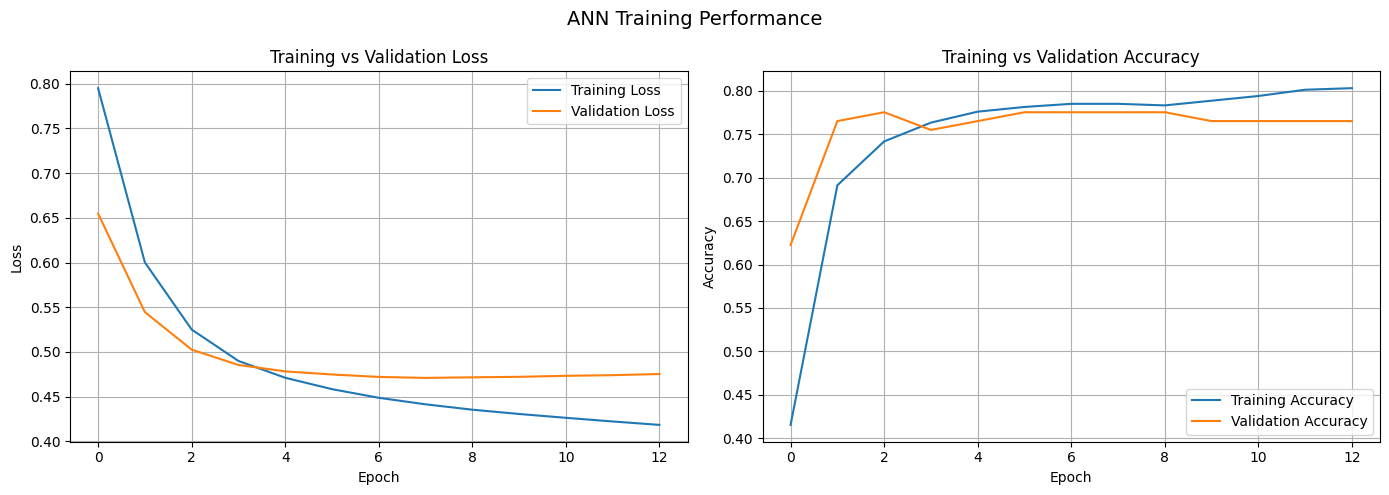

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(
history.history['loss'],
label='Training Loss'
)

ax[0].plot(
history.history['val_loss'],
label='Validation Loss'
)

ax[0].set_title('Training vs Validation Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(
history.history['accuracy'],
label='Training Accuracy'
)

ax[1].plot(
history.history['val_accuracy'],
label='Validation Accuracy'
)

ax[1].set_title('Training vs Validation Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[1].grid(True)

plt.suptitle('ANN Training Performance', fontsize=14)

plt.tight_layout()
plt.show()

Secara keseluruhan, model ANN ini sudah menunjukkan performa awal yang cukup baik dengan akurasi validasi mencapai 77%. Namun, untuk mengatasi gejala *overfitting* yang mulai muncul setelah *epoch* ke-4, beberapa strategi optimasi dapat diterapkan pada iterasi selanjutnya. Langkah-langkah tersebut meliputi penerapan **Early Stopping** untuk menghentikan latihan saat *validation loss* mulai stagnan, penambahan **Layer Dropout** (seperti Dropout 0.2 atau 0.5) guna mengurangi ketergantungan antar-neuron, penggunaan **Regularisasi L2** untuk membatasi kompleksitas bobot jaringan, serta penambahan variasi data melalui **Data Augmentation** agar model mampu mengenali pola klinis yang lebih umum secara lebih general.

In [ ]:
from sklearn.metrics import classification_report

def evaluasi_ann_model(model, X_data, y_data, data_name):

    y_pred_prob = model.predict(X_data)

    y_pred = (y_pred_prob > 0.5).astype(int)
    y_pred = y_pred.flatten()

    acc_ann = accuracy_score(y_data, y_pred)
    prec_ann = precision_score(y_data, y_pred)
    rec_ann = recall_score(y_data, y_pred)
    f1_ann = f1_score(y_data, y_pred)

    print(f"\n===== {data_name} =====")
    print(f"Accuracy  : {acc_ann:.4f}")
    print(f"Precision : {prec_ann:.4f}")
    print(f"Recall    : {rec_ann:.4f}")
    print(f"F1-Score  : {f1_ann:.4f}")

    print("\nClassification Report")
    print(
        classification_report(
            y_data,
            y_pred,
            target_names=['No Diabetes', 'Diabetes']
        )
    )
    return acc_ann, prec_ann, rec_ann, f1_ann

In [ ]:
acc_ann, prec_ann, rec_ann, f1_ann = evaluasi_ann_model(
    model,
    X_test_scaled,
    y_test,
    "ANN Test Set"
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step

===== ANN Test Set =====
Accuracy  : 0.7845
Precision : 0.6744
Recall    : 0.7250
F1-Score  : 0.6988

Classification Report
              precision    recall  f1-score   support

 No Diabetes       0.85      0.82      0.83        76
    Diabetes       0.67      0.72      0.70        40

    accuracy                           0.78       116
   macro avg       0.76      0.77      0.77       116
weighted avg       0.79      0.78      0.79       116



4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


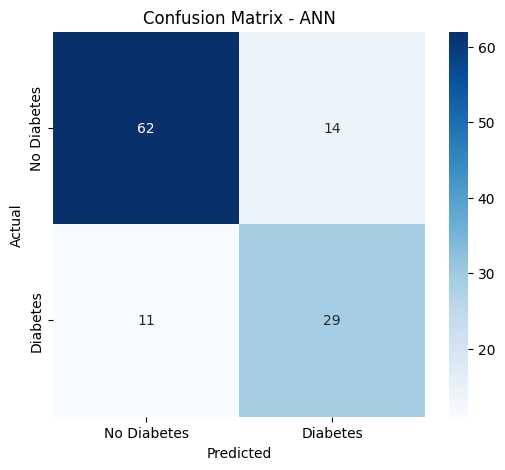

In [ ]:
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title('Confusion Matrix - ANN')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [ ]:
hasil_model = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Artificial Neural Network'
    ],
    'Accuracy': [
        acc_logreg,
        acc_rf,
        acc_ann
    ],
    'Precision': [
        prec_logreg,
        prec_rf,
        prec_ann
    ],
    'Recall': [
        rec_logreg,
        rec_rf,
        rec_ann
    ],
    'F1-Score': [
        f1_logreg,
        f1_rf,
        f1_ann
    ]
})

hasil_model.sort_values(
    by='F1-Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score
2,Artificial Neural Network,0.784483,0.674419,0.725000,0.698795
1,Random Forest,0.759740,0.680851,0.592593,0.633663
0,Logistic Regression,0.688312,0.560000,0.518519,0.538462


Berdasarkan tabel hasil eksekusi di atas, berikut adalah urutan performa model dari yang terbaik hingga terendah:

1. Artificial Neural Network (ANN) * Accuracy: 78.45% | Precision: 67.44% | Recall: 72.50% | F1-Score: 69.88%

- Analisis: Model ANN menempati peringkat pertama dengan nilai F1-Score dan akurasi tertinggi. Model ini memiliki kemampuan Recall yang superior (72.50%), yang berarti jaringan saraf tiruan mampu meminimalkan risiko pasien diabetes yang salah terdeteksi sebagai sehat (False Negative). Hal ini sangat krusial dalam konteks medis.

2. Random Forest * Accuracy: 75.97% | Precision: 68.09% | Recall: 59.26% | F1-Score: 63.37%

- Analisis: Model berbasis ensemble tree ini menempati posisi kedua. Meskipun memiliki tingkat tingkat kepastian prediksi positif (Precision) sedikit lebih tinggi dibandingkan ANN, nilai Recall-nya jatuh cukup signifikan. Artinya, masih ada cukup banyak pasien diabetes riil yang gagal diidentifikasi oleh model ini.

3. Logistic Regression * Accuracy: 68.83% | Precision: 56.00% | Recall: 51.85% | F1-Score: 53.85%

- Analisis: Sebagai baseline model, Logistic Regression menunjukkan performa paling rendah di antara ketiganya. Hal ini mengindikasikan bahwa hubungan antar-fitur klinis dalam dataset ini memiliki pola non-linear kompleks yang sulit ditangkap secara optimal oleh model linear sederhana.

# Save Model ke joblib

In [ ]:
import os
import joblib
import tensorflow as tf

loc_model_save = "saved_models"
os.makedirs(loc_model_save, exist_ok=True)

joblib.dump(scaler, os.path.join(loc_model_save, "ml_scaler.joblib"))
joblib.dump(scaler, os.path.join(loc_model_save, 'robust_scaler.pkl'))
print("Scaler berhasil disimpan!")

joblib.dump(hasil_logreg, os.path.join(loc_model_save, 'logistic_regression_model.pkl'))
print("Model Linear / Logistic Regression berhasil disimpan!")

model.save(os.path.join(loc_model_save, "ann_model.keras"))
print("Model ANN (.keras) berhasil disimpan!")

model.save(os.path.join(loc_model_save, "ann_model.h5"))
print("Model ANN (.h5) berhasil disimpan!")

Scaler berhasil disimpan!
Model Linear / Logistic Regression berhasil disimpan!
Model ANN (.keras) berhasil disimpan!
Model ANN (.h5) berhasil disimpan!


In [ ]:
from google.colab import files

files.download("saved_models/ml_scaler.joblib")
files.download("saved_models/robust_scaler.pkl")
files.download("saved_models/logistic_regression_model.pkl")
files.download("saved_models/ann_model.keras")
files.download("saved_models/ann_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>